<a href="https://colab.research.google.com/github/yixiaoyan-77/A-Controlled-Study-of-Counterfactual-Failure-in-Small-Language-Models/blob/main/dsai5207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 安装依赖

In [ ]:
!pip install -q transformers datasets scikit-learn

2. 导入库

In [ ]:
import numpy as np
import re
from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import torch
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

3. 加载数据

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict

# 用逗号分隔，第一行是表头
train_df = pd.read_csv("/content/drive/MyDrive/DSAI5207/subtask1_train.csv", sep=",", header=0)
test_df  = pd.read_csv("/content/drive/MyDrive/DSAI5207/subtask1_test.csv", sep=",", header=0)

# 查看列名和前几行
print("列名:", train_df.columns.tolist())
print(train_df.head(2))

# 重命名列，方便后续处理
train_df = train_df.rename(columns={"sentence": "text", "gold_label": "label"})
test_df  = test_df.rename(columns={"sentence": "text", "gold_label": "label"})

# 只保留需要的两列
train_df = train_df[["text", "label"]]
test_df  = test_df[["text", "label"]]

# 标签映射（gold_label 已经是 0/1 数字，但确认一下）
print("标签类型:", train_df["label"].dtype)
print("标签示例:", train_df["label"].unique())

# 如果意外是字符串（极少情况），可以做映射，但这里应该直接是 int
# 保险起见，转为 int
train_df["label"] = train_df["label"].astype(int)
test_df["label"]  = test_df["label"].astype(int)

raw_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test":  Dataset.from_pandas(test_df),
})

print(f"训练集大小: {len(raw_dataset['train'])}")
print(f"测试集大小: {len(raw_dataset['test'])}")
print(f"标签分布: {train_df['label'].value_counts().to_dict()}")

列名: ['sentenceID', 'gold_label', 'sentence']
   sentenceID  gold_label                                           sentence
0      100000           1  Goodfellow's theory has been questioned, howev...
1      100001           1  However, both campaigners and pro-People's Vot...
标签类型: int64
标签示例: [1 0]
训练集大小: 13000
测试集大小: 7000
标签分布: {0: 11546, 1: 1454}


4. 词汇扰动定义

In [ ]:
LEX_MARKERS = [
    "if", "would", "could", "might", "should", "suppose",
    "imagine", "otherwise", "had", "were", "ought"
]
def remove_markers(text):
    pattern = r'\b(?:' + '|'.join(LEX_MARKERS) + r')\b'
    cleaned = re.sub(pattern, '', text, flags=re.IGNORECASE)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

5. 预处理

In [ ]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_datasets = raw_dataset.map(tokenize_function, batched=True)

# 构造扰动测试集
def create_perturbed_test_dataset(dataset):
    def apply_perturbation(examples):
        perturbed_texts = [remove_markers(t) for t in examples["text"]]
        return tokenizer(perturbed_texts, truncation=True, padding="max_length", max_length=128)
    return dataset.map(apply_perturbation, batched=True)

perturbed_test = create_perturbed_test_dataset(raw_dataset["test"])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/13000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

6. 微调

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)

print("开始训练 DistilBERT...")
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


开始训练 DistilBERT...


Epoch,Training Loss,Validation Loss
1,0.112038,0.140476
2,0.078404,0.128732
3,0.040889,0.141944


TrainOutput(global_step=2439, training_loss=0.10492297888486392, metrics={'train_runtime': 506.7334, 'train_samples_per_second': 76.964, 'train_steps_per_second': 4.813, 'total_flos': 1291557136896000.0, 'train_loss': 0.10492297888486392, 'epoch': 3.0})

7. 评估

In [ ]:
def compute_accuracy(trainer, test_dataset):
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=1)
    labels = predictions.label_ids
    return accuracy_score(labels, preds)

acc_orig = compute_accuracy(trainer, tokenized_datasets["test"])
acc_pert = compute_accuracy(trainer, perturbed_test)

print(f"\n===== 结果 =====")
print(f"原始测试集准确率: {acc_orig:.4f}")
print(f"扰动测试集准确率: {acc_pert:.4f}")
print(f"下降值 (drop):   {acc_orig - acc_pert:.4f}")


===== 结果 =====
原始测试集准确率: 0.9661
扰动测试集准确率: 0.9111
下降值 (drop):   0.0550


8. 词汇基线

In [ ]:
def lexical_baseline_predict(texts):
    pattern = re.compile(r'\b(?:' + '|'.join(LEX_MARKERS) + r')\b', re.IGNORECASE)
    return [1 if pattern.search(t) else 0 for t in texts]

test_texts_orig = raw_dataset["test"]["text"]
test_labels_orig = raw_dataset["test"]["label"]
lex_acc_orig = accuracy_score(test_labels_orig, lexical_baseline_predict(test_texts_orig))

perturbed_texts = [remove_markers(t) for t in test_texts_orig]
lex_acc_pert = accuracy_score(test_labels_orig, lexical_baseline_predict(perturbed_texts))

print(f"词汇基线准确率 (原测试集): {lex_acc_orig:.4f}")
print(f"词汇基线准确率 (扰动集):   {lex_acc_pert:.4f}")
print(f"词汇基线下降值:            {lex_acc_orig - lex_acc_pert:.4f}")

词汇基线准确率 (原测试集): 0.1550
词汇基线准确率 (扰动集):   0.8946
词汇基线下降值:            -0.7396


9. 表征探测实验

反事实句子比例: 0.105
含有标记词的句子比例: 0.942


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


正在提取表征（可能需要几分钟）...
提取完成，共 7 层（含嵌入层）。
Layer 0: 探针A(反事实) acc=0.899 | 探针B(词汇) acc=0.062
Layer 1: 探针A(反事实) acc=0.819 | 探针B(词汇) acc=0.872
Layer 2: 探针A(反事实) acc=0.823 | 探针B(词汇) acc=0.886
Layer 3: 探针A(反事实) acc=0.807 | 探针B(词汇) acc=0.881
Layer 4: 探针A(反事实) acc=0.829 | 探针B(词汇) acc=0.875
Layer 5: 探针A(反事实) acc=0.854 | 探针B(词汇) acc=0.881
Layer 6: 探针A(反事实) acc=0.877 | 探针B(词汇) acc=0.881


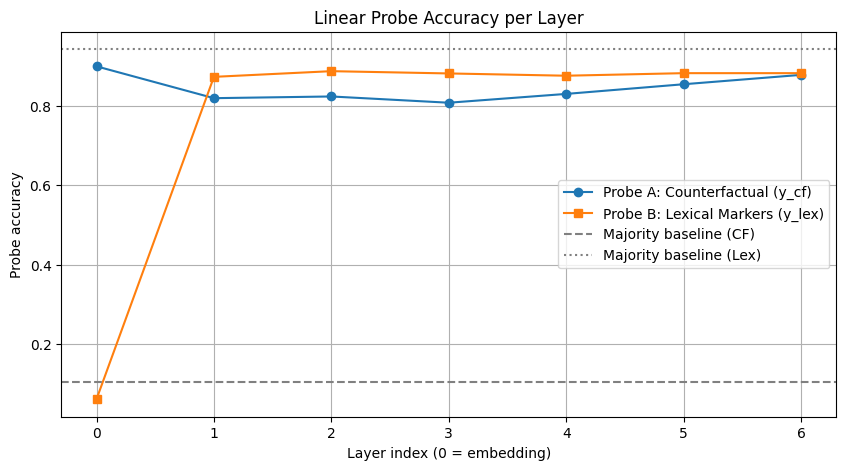

In [ ]:
# ==================== 表征探测实验 ====================
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import re
import matplotlib.pyplot as plt

# ---------- 1. 准备句子与标签 ----------
# 直接从 raw_dataset 中取出测试集文本和标签（保持和之前一样）
texts = raw_dataset["test"]["text"]
labels_cf = np.array(raw_dataset["test"]["label"])  # 0/1，是否是反事实

# 构建词汇标记存在性标签 y_lex
LEX_MARKERS = [
    "if", "would", "could", "might", "should", "suppose",
    "imagine", "otherwise", "had", "were", "ought"
]
pattern_lex = re.compile(r'\b(?:' + '|'.join(LEX_MARKERS) + r')\b', re.IGNORECASE)
labels_lex = np.array([1 if pattern_lex.search(t) else 0 for t in texts])

print(f"反事实句子比例: {labels_cf.mean():.3f}")
print(f"含有标记词的句子比例: {labels_lex.mean():.3f}")

# ---------- 2. 加载未微调的模型 ----------
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_hidden_states=True)
model.eval()

# 如果有 GPU，移动到 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ---------- 3. 提取每一层的句子表征（用 [CLS]） ----------
def extract_layer_representations(text_list, model, tokenizer, device, batch_size=32):
    all_hidden = {i: [] for i in range(model.config.num_hidden_layers + 1)}  # 包括嵌入层
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True,
                           padding=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        # hidden_states 是一个元组，长度 = num_hidden_layers + 1 (embedding + each layer)
        hidden_states = outputs.hidden_states  # 每层的 hidden states, shape: (batch, seq_len, hidden_dim)
        for layer_idx, state in enumerate(hidden_states):
            # 取 [CLS] token (index 0)
            cls_rep = state[:, 0, :].cpu().numpy()
            all_hidden[layer_idx].append(cls_rep)
    # 拼接所有 batch
    for layer_idx in all_hidden:
        all_hidden[layer_idx] = np.concatenate(all_hidden[layer_idx], axis=0)
    return all_hidden

print("正在提取表征（可能需要几分钟）...")
layer_reps = extract_layer_representations(texts, model, tokenizer, device)
num_layers = len(layer_reps)
print(f"提取完成，共 {num_layers} 层（含嵌入层）。")

# ---------- 4. 划分探测训练集与测试集（80/20） ----------
train_idx, test_idx = train_test_split(np.arange(len(texts)), test_size=0.2, random_state=42)

# ---------- 5. 逐层训练探针并记录准确率 ----------
probe_acc_cf = []   # 探针 A：预测反事实
probe_acc_lex = []  # 探针 B：预测词汇标记

for layer in range(num_layers):
    X_train = layer_reps[layer][train_idx]
    X_test  = layer_reps[layer][test_idx]

    # 探针 A
    clf_a = LogisticRegression(max_iter=1000, class_weight='balanced')  # 平衡类别权重
    clf_a.fit(X_train, labels_cf[train_idx])
    pred_a = clf_a.predict(X_test)
    acc_a = accuracy_score(labels_cf[test_idx], pred_a)

    # 探针 B
    clf_b = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf_b.fit(X_train, labels_lex[train_idx])
    pred_b = clf_b.predict(X_test)
    acc_b = accuracy_score(labels_lex[test_idx], pred_b)

    probe_acc_cf.append(acc_a)
    probe_acc_lex.append(acc_b)

    print(f"Layer {layer}: 探针A(反事实) acc={acc_a:.3f} | 探针B(词汇) acc={acc_b:.3f}")

# ---------- 6. 绘图 ----------
plt.figure(figsize=(10, 5))
layers = list(range(num_layers))
plt.plot(layers, probe_acc_cf, marker='o', label='Probe A: Counterfactual (y_cf)')
plt.plot(layers, probe_acc_lex, marker='s', label='Probe B: Lexical Markers (y_lex)')
plt.axhline(y=labels_cf.mean(), color='gray', linestyle='--', label='Majority baseline (CF)')
plt.axhline(y=labels_lex.mean(), color='gray', linestyle=':', label='Majority baseline (Lex)')
plt.xlabel("Layer index (0 = embedding)")
plt.ylabel("Probe accuracy")
plt.title("Linear Probe Accuracy per Layer")
plt.legend()
plt.grid(True)
plt.show()

10. 泛化探针实验

反事实比例: 0.105
含标记词比例: 0.942


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


正在提取表征...
训练集大小 (含标记词): 6591
测试集大小 (不含标记词): 409
测试集中反事实比例: 0.076
Layer 0: F1=0.480, Acc=0.924
Layer 1: F1=0.634, Acc=0.800
Layer 2: F1=0.636, Acc=0.807
Layer 3: F1=0.602, Acc=0.790
Layer 4: F1=0.607, Acc=0.790
Layer 5: F1=0.634, Acc=0.814
Layer 6: F1=0.678, Acc=0.839


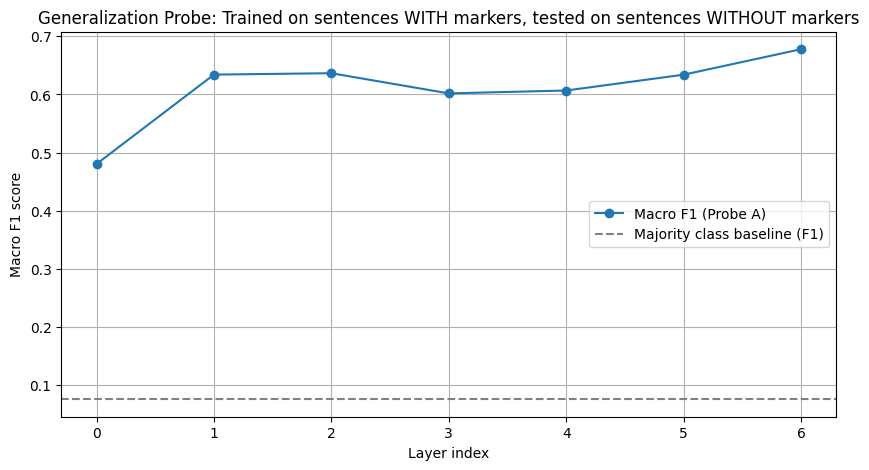

In [ ]:
# ==================== 泛化探针与 F1 评估 ====================
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import re
import matplotlib.pyplot as plt

# ---------- 1. 准备数据 ----------
texts = raw_dataset["test"]["text"]
labels_cf = np.array(raw_dataset["test"]["label"])

LEX_MARKERS = [
    "if", "would", "could", "might", "should", "suppose",
    "imagine", "otherwise", "had", "were", "ought"
]
pattern_lex = re.compile(r'\b(?:' + '|'.join(LEX_MARKERS) + r')\b', re.IGNORECASE)
labels_lex = np.array([1 if pattern_lex.search(t) else 0 for t in texts])

print(f"反事实比例: {labels_cf.mean():.3f}")
print(f"含标记词比例: {labels_lex.mean():.3f}")

# ---------- 2. 加载模型并提取表征 ----------
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_hidden_states=True)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def extract_layer_representations(text_list, model, tokenizer, device, batch_size=32):
    all_hidden = {i: [] for i in range(model.config.num_hidden_layers + 1)}
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True,
                           padding=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        hidden_states = outputs.hidden_states
        for layer_idx, state in enumerate(hidden_states):
            cls_rep = state[:, 0, :].cpu().numpy()
            all_hidden[layer_idx].append(cls_rep)
    for layer_idx in all_hidden:
        all_hidden[layer_idx] = np.concatenate(all_hidden[layer_idx], axis=0)
    return all_hidden

print("正在提取表征...")
layer_reps = extract_layer_representations(texts, model, tokenizer, device)
num_layers = len(layer_reps)

# ---------- 3. 构建跨分布训练/测试划分 ----------
# 训练集：仅含标记词 (labels_lex == 1)
train_mask = labels_lex == 1
# 测试集：仅不含标记词 (labels_lex == 0)
test_mask = labels_lex == 0

X_train_cf = {l: layer_reps[l][train_mask] for l in range(num_layers)}
y_train_cf = labels_cf[train_mask]
X_test_cf  = {l: layer_reps[l][test_mask] for l in range(num_layers)}
y_test_cf  = labels_cf[test_mask]

print(f"训练集大小 (含标记词): {len(y_train_cf)}")
print(f"测试集大小 (不含标记词): {len(y_test_cf)}")
print(f"测试集中反事实比例: {y_test_cf.mean():.3f}")

# ---------- 4. 逐层训练探针并计算 F1 和准确率 ----------
probe_f1 = []   # 宏平均 F1
probe_acc = []  # 准确率

for layer in range(num_layers):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_cf[layer], y_train_cf)
    preds = clf.predict(X_test_cf[layer])
    f1 = f1_score(y_test_cf, preds, average='macro')  # 宏平均 F1，不受不平衡影响
    acc = accuracy_score(y_test_cf, preds)
    probe_f1.append(f1)
    probe_acc.append(acc)
    print(f"Layer {layer}: F1={f1:.3f}, Acc={acc:.3f}")

# ---------- 5. 绘制 ----------
plt.figure(figsize=(10,5))
layers = list(range(num_layers))
plt.plot(layers, probe_f1, marker='o', label='Macro F1 (Probe A)')
plt.axhline(y=y_test_cf.mean(), color='gray', linestyle='--', label='Majority class baseline (F1)')
# 同时展示词汇探针的 F1 作为参考（可选，你之前的词汇探针 B 也可画出来，此略）
plt.xlabel("Layer index")
plt.ylabel("Macro F1 score")
plt.title("Generalization Probe: Trained on sentences WITH markers, tested on sentences WITHOUT markers")
plt.legend()
plt.grid(True)
plt.show()

# 同时保存之前的探针B的F1对比，快速计算（无需重新训练，但为简洁，先省略）

11. BERT-base

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/13000 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss
1,0.121197,0.140352
2,0.057829,0.149220
3,0.021622,0.185591


BERT-base 原始准确率: 0.9703
BERT-base 扰动准确率: 0.9197
下降值: 0.0506


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


提取 BERT-base 表征...
Layer 0: F1=0.480, Acc=0.924
Layer 2: F1=0.625, Acc=0.804
Layer 4: F1=0.627, Acc=0.807
Layer 6: F1=0.661, Acc=0.831
Layer 8: F1=0.670, Acc=0.831
Layer 10: F1=0.669, Acc=0.839
Layer 12: F1=0.690, Acc=0.853


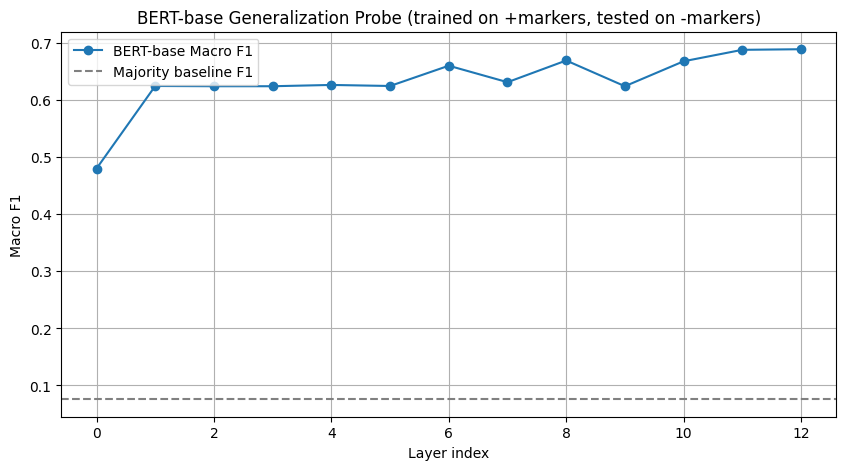

词汇基线 原测试集: 0.1550, 扰动集: 0.8946


In [ ]:
# ==================== 数据重新加载（若 raw_dataset 丢失） ====================
import pandas as pd
from datasets import Dataset, DatasetDict

train_df = pd.read_csv("/content/drive/MyDrive/DSAI5207/subtask1_train.csv", sep=",", header=0)
test_df  = pd.read_csv("/content/drive/MyDrive/DSAI5207/subtask1_test.csv", sep=",", header=0)

train_df = train_df.rename(columns={"sentence": "text", "gold_label": "label"})
test_df  = test_df.rename(columns={"sentence": "text", "gold_label": "label"})
train_df = train_df[["text", "label"]]
test_df  = test_df[["text", "label"]]
train_df["label"] = train_df["label"].astype(int)
test_df["label"]  = test_df["label"].astype(int)

raw_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test":  Dataset.from_pandas(test_df),
})

# ==================== BERT-base 完整实验 ====================
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel, TrainingArguments, Trainer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings("ignore")

# ---------- 1. 词汇扰动定义 ----------
LEX_MARKERS = [
    "if", "would", "could", "might", "should", "suppose",
    "imagine", "otherwise", "had", "were", "ought"
]
def remove_markers(text):
    pattern = r'\b(?:' + '|'.join(LEX_MARKERS) + r')\b'
    cleaned = re.sub(pattern, '', text, flags=re.IGNORECASE)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

# ---------- 2. 预处理 ----------
model_name = "bert-base-uncased"   # <--- 修改点 1
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_datasets = raw_dataset.map(tokenize_function, batched=True)

def create_perturbed_test_dataset(dataset):
    def apply_perturbation(examples):
        perturbed_texts = [remove_markers(t) for t in examples["text"]]
        return tokenizer(perturbed_texts, truncation=True, padding="max_length", max_length=128)
    return dataset.map(apply_perturbation, batched=True)

perturbed_test = create_perturbed_test_dataset(raw_dataset["test"])

# ---------- 3. 微调 ----------
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

training_args = TrainingArguments(
    output_dir="./results_bert",
    eval_strategy="epoch",
    save_strategy="no",
    num_train_epochs=3,
    per_device_train_batch_size=8,    # <--- 修改点 2：减小 batch size 防止 OOM
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)

print("开始训练 BERT-base...")
trainer.train()

# ---------- 4. 扰动评估 ----------
def compute_accuracy(trainer, test_dataset):
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=1)
    labels = predictions.label_ids
    return accuracy_score(labels, preds)

acc_orig = compute_accuracy(trainer, tokenized_datasets["test"])
acc_pert = compute_accuracy(trainer, perturbed_test)

print(f"BERT-base 原始准确率: {acc_orig:.4f}")
print(f"BERT-base 扰动准确率: {acc_pert:.4f}")
print(f"下降值: {acc_orig - acc_pert:.4f}")

# ---------- 5. 泛化探针 ----------
texts = raw_dataset["test"]["text"]
labels_cf = np.array(raw_dataset["test"]["label"])
pattern_lex = re.compile(r'\b(?:' + '|'.join(LEX_MARKERS) + r')\b', re.IGNORECASE)
labels_lex = np.array([1 if pattern_lex.search(t) else 0 for t in texts])

# 加载未微调模型用于表征提取
probe_model = AutoModel.from_pretrained(model_name, output_hidden_states=True)
probe_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
probe_model.to(device)

def extract_layer_representations(text_list, model, tokenizer, device, batch_size=16):  # 提取时可稍大
    all_hidden = {i: [] for i in range(model.config.num_hidden_layers + 1)}
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True,
                           padding=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        hidden_states = outputs.hidden_states
        for layer_idx, state in enumerate(hidden_states):
            cls_rep = state[:, 0, :].cpu().numpy()
            all_hidden[layer_idx].append(cls_rep)
    for layer_idx in all_hidden:
        all_hidden[layer_idx] = np.concatenate(all_hidden[layer_idx], axis=0)
    return all_hidden

print("提取 BERT-base 表征...")
layer_reps = extract_layer_representations(texts, probe_model, tokenizer, device, batch_size=16)

# 跨分布划分
train_mask = labels_lex == 1
test_mask = labels_lex == 0
X_train_cf = {l: layer_reps[l][train_mask] for l in range(len(layer_reps))}
y_train_cf = labels_cf[train_mask]
X_test_cf  = {l: layer_reps[l][test_mask] for l in range(len(layer_reps))}
y_test_cf  = labels_cf[test_mask]

probe_f1 = []
probe_acc = []
for layer in range(len(layer_reps)):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_cf[layer], y_train_cf)
    preds = clf.predict(X_test_cf[layer])
    f1 = f1_score(y_test_cf, preds, average='macro')
    acc = accuracy_score(y_test_cf, preds)
    probe_f1.append(f1)
    probe_acc.append(acc)
    if layer % 2 == 0 or layer == len(layer_reps)-1:  # 每隔几层打印
        print(f"Layer {layer}: F1={f1:.3f}, Acc={acc:.3f}")

# 绘图
plt.figure(figsize=(10,5))
plt.plot(range(len(layer_reps)), probe_f1, marker='o', label='BERT-base Macro F1')
plt.axhline(y=y_test_cf.mean(), color='gray', linestyle='--', label='Majority baseline F1')
plt.xlabel("Layer index")
plt.ylabel("Macro F1")
plt.title("BERT-base Generalization Probe (trained on +markers, tested on -markers)")
plt.legend(); plt.grid(True); plt.show()

# 词汇基线
def lexical_baseline_predict(texts):
    return [1 if pattern_lex.search(t) else 0 for t in texts]

lex_acc_orig = accuracy_score(labels_cf, lexical_baseline_predict(texts))
perturbed_texts = [remove_markers(t) for t in texts]
lex_acc_pert = accuracy_score(labels_cf, lexical_baseline_predict(perturbed_texts))
print(f"词汇基线 原测试集: {lex_acc_orig:.4f}, 扰动集: {lex_acc_pert:.4f}")

In [ ]:
probe_f1 = []
probe_acc = []
for layer in range(len(layer_reps)):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_cf[layer], y_train_cf)
    preds = clf.predict(X_test_cf[layer])
    f1 = f1_score(y_test_cf, preds, average='macro')
    acc = accuracy_score(y_test_cf, preds)
    probe_f1.append(f1)
    probe_acc.append(acc)
    print(f"Layer {layer}: F1={f1:.3f}, Acc={acc:.3f}")

Layer 0: F1=0.480, Acc=0.924
Layer 1: F1=0.625, Acc=0.790
Layer 2: F1=0.625, Acc=0.804
Layer 3: F1=0.625, Acc=0.804
Layer 4: F1=0.627, Acc=0.807
Layer 5: F1=0.625, Acc=0.790
Layer 6: F1=0.661, Acc=0.831
Layer 7: F1=0.632, Acc=0.807
Layer 8: F1=0.670, Acc=0.831
Layer 9: F1=0.625, Acc=0.804
Layer 10: F1=0.669, Acc=0.839
Layer 11: F1=0.689, Acc=0.861
Layer 12: F1=0.690, Acc=0.853


12. 绘制图片

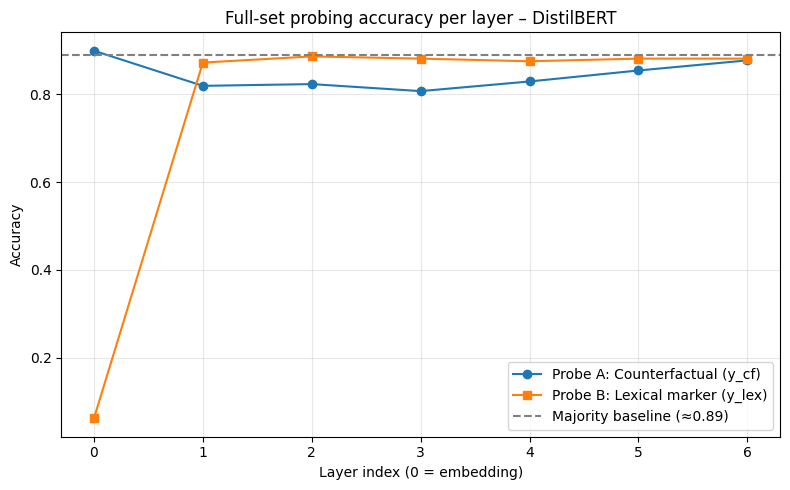

In [ ]:
import matplotlib.pyplot as plt

# DistilBERT 全量探针准确率
layers = [0,1,2,3,4,5,6]
probe_a_cf = [0.899, 0.819, 0.823, 0.807, 0.829, 0.854, 0.877]
probe_b_lex = [0.062, 0.872, 0.886, 0.881, 0.875, 0.881, 0.881]

plt.figure(figsize=(8,5))
plt.plot(layers, probe_a_cf, 'o-', label='Probe A: Counterfactual (y_cf)')
plt.plot(layers, probe_b_lex, 's-', label='Probe B: Lexical marker (y_lex)')
plt.axhline(y=0.889, color='gray', linestyle='--', label='Majority baseline (≈0.89)')
plt.xlabel('Layer index (0 = embedding)')
plt.ylabel('Accuracy')
plt.title('Full-set probing accuracy per layer – DistilBERT')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure1_full_probe.pdf')
plt.show()

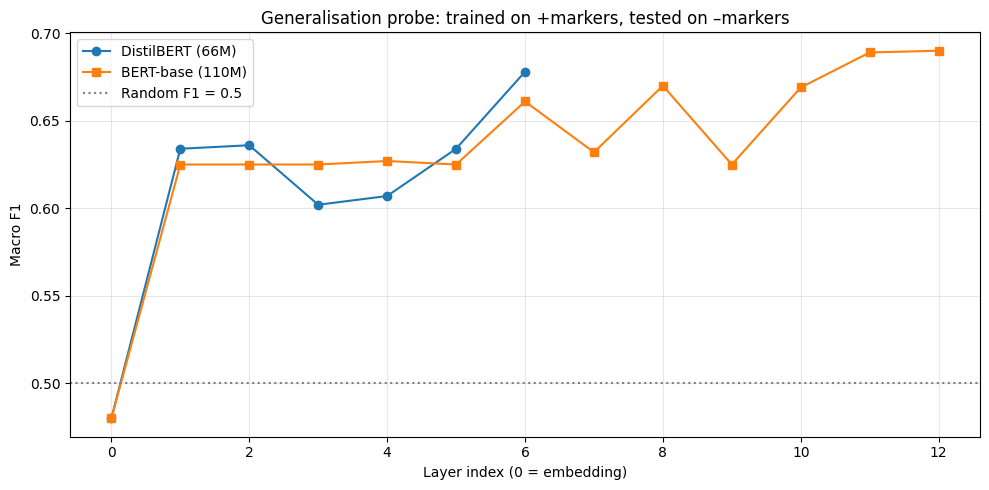

In [ ]:
import matplotlib.pyplot as plt

# 泛化探针 F1
layers_distil = list(range(7))
f1_distil = [0.480, 0.634, 0.636, 0.602, 0.607, 0.634, 0.678]

layers_bert = list(range(13))
f1_bert = [0.480, 0.625, 0.625, 0.625, 0.627, 0.625, 0.661, 0.632, 0.670, 0.625, 0.669, 0.689, 0.690]

plt.figure(figsize=(10,5))
plt.plot(layers_distil, f1_distil, 'o-', label='DistilBERT (66M)')
plt.plot(layers_bert, f1_bert, 's-', label='BERT-base (110M)')
plt.axhline(y=0.5, color='gray', linestyle=':', label='Random F1 = 0.5')
plt.xlabel('Layer index (0 = embedding)')
plt.ylabel('Macro F1')
plt.title('Generalisation probe: trained on +markers, tested on –markers')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure2_generalisation_f1.pdf')
plt.show()